In [1]:
from scipy.io import loadmat

In [10]:
import pandas as pd

path = "../data/raw/Ninapro_DB1.csv"

df = pd.read_csv(path)

df.head()

,Unnamed: 0,emg_0,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,...,glove_18,glove_19,glove_20,glove_21,exercise,stimulus,restimulus,repetition,rerepetition,subject
0,0,0.0024,0.0024,0.0024,0.0024,0.0024,0.0098,0.0146,0.0488,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10
1,1,0.0024,0.0024,0.0024,0.0024,0.0024,0.0098,0.0122,0.0439,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10
2,2,0.0024,0.0024,0.0024,0.0024,0.0024,0.0073,0.0073,0.0366,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10
3,3,0.0049,0.0024,0.0024,0.0024,0.0024,0.0073,0.0049,0.0317,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10
4,4,0.0049,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0293,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10


In [12]:
df.shape

(12553611, 39)

In [13]:
df.columns

Index(['Unnamed: 0', 'emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5',
       'emg_6', 'emg_7', 'emg_8', 'emg_9', 'glove_0', 'glove_1', 'glove_2',
       'glove_3', 'glove_4', 'glove_5', 'glove_6', 'glove_7', 'glove_8',
       'glove_9', 'glove_10', 'glove_11', 'glove_12', 'glove_13', 'glove_14',
       'glove_15', 'glove_16', 'glove_17', 'glove_18', 'glove_19', 'glove_20',
       'glove_21', 'exercise', 'stimulus', 'restimulus', 'repetition',
       'rerepetition', 'subject'],
      dtype='object')

In [14]:
emg_cols = [
    c for c in df.columns if "emg" in c.lower()
]
emg_cols

['emg_0',
 'emg_1',
 'emg_2',
 'emg_3',
 'emg_4',
 'emg_5',
 'emg_6',
 'emg_7',
 'emg_8',
 'emg_9']

In [17]:
df['stimulus'].value_counts()

stimulus
0     5294877
8      420471
12     419520
4      419478
7      419464
2      419432
6      418556
9      418552
5      418505
11     418499
3      417616
10     417578
1      417504
13     280582
14     279719
17     279675
15     278701
16     277785
19     140629
21     139880
18     139853
20     138972
22     138894
23     138869
Name: count, dtype: int64

In [19]:
import matplotlib.pyplot as plt

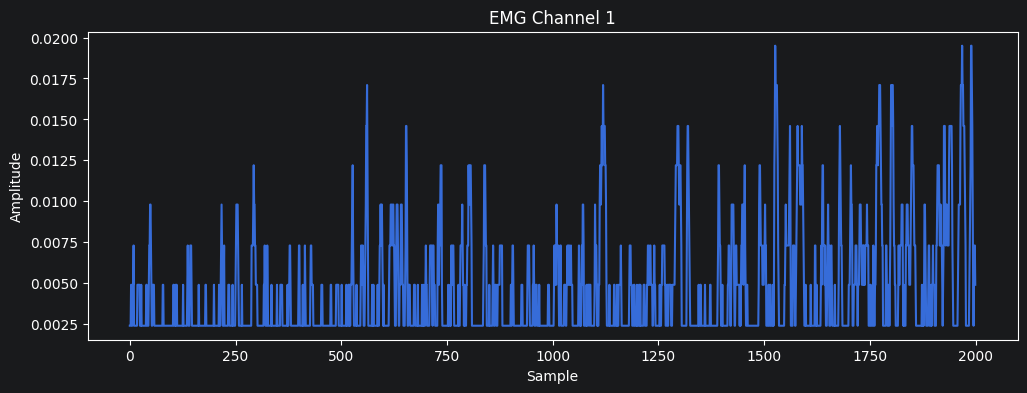

In [21]:
plt.figure(figsize=(12,4))


plt.plot(
    df['emg_0'][:2000]
)


plt.title("EMG Channel 1")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.show()

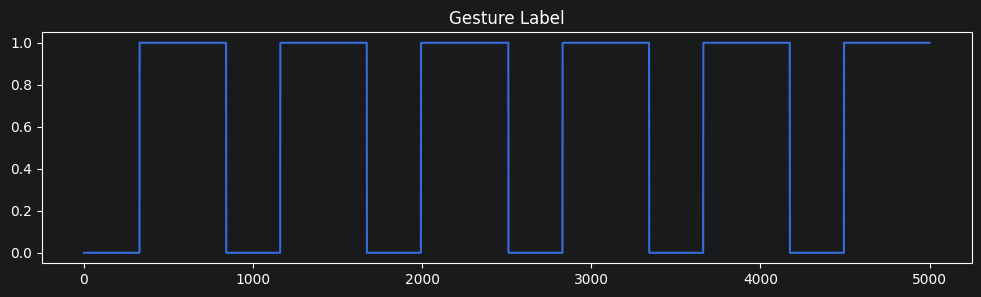

In [24]:
plt.figure(figsize=(12,3))

plt.plot(
    df['stimulus'][:5000]
)

plt.title("Gesture Label")

plt.show()

In [25]:
df[emg_cols].head()

,emg_0,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,emg_9
0,0.0024,0.0024,0.0024,0.0024,0.0024,0.0098,0.0146,0.0488,0.0024,0.0317
1,0.0024,0.0024,0.0024,0.0024,0.0024,0.0098,0.0122,0.0439,0.0024,0.0317
2,0.0024,0.0024,0.0024,0.0024,0.0024,0.0073,0.0073,0.0366,0.0024,0.0293
3,0.0049,0.0024,0.0024,0.0024,0.0024,0.0073,0.0049,0.0317,0.0024,0.0269
4,0.0049,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0293,0.0024,0.0220


In [26]:
df["subject"].value_counts()

subject
15    478193
21    474360
17    473988
2     472501
11    471954
1     471483
20    469983
25    469821
24    469559
22    468122
3     467777
19    467289
23    466726
27    466175
18    465533
7     465343
26    463778
14    461607
9     461355
12    460382
10    457928
5     457542
16    456828
13    456617
4     455868
6     453169
8     449730
Name: count, dtype: int64

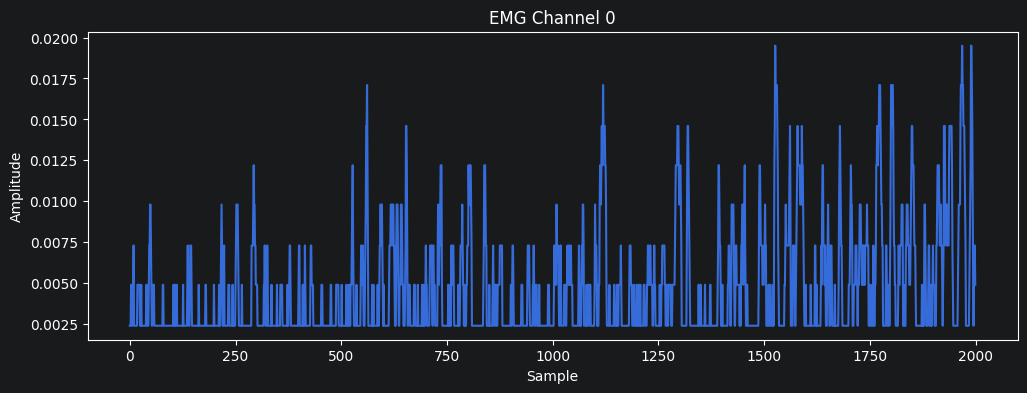

In [27]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,4))

plt.plot(
    df['emg_0'][:2000]
)

plt.title("EMG Channel 0")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.show()

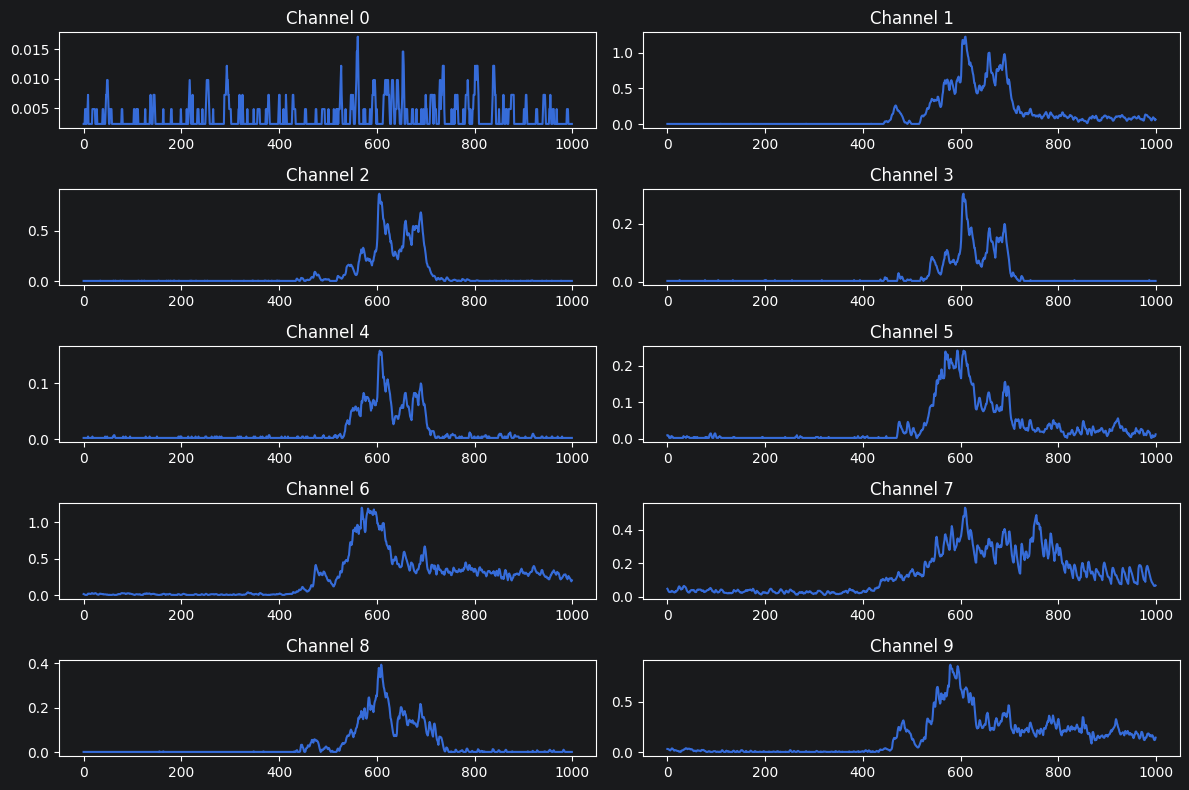

In [28]:
plt.figure(figsize=(12,8))

for i in range(10):

    plt.subplot(5,2,i+1)

    plt.plot(
        df[f'emg_{i}'][:1000]
    )

    plt.title(
        f"Channel {i}"
    )

plt.tight_layout()

plt.show()

In [29]:
df.shape

(12553611, 39)

In [30]:
df_action = df[df["stimulus"] != 0]
df_action.shape

(7258734, 39)

In [31]:
emg_cols = [
    f"emg_{i}" for i in range(10)
]
X = df_action[emg_cols].values
y = df_action["stimulus"].values
subject = df_action["subject"].values

In [33]:
print(X.shape)
print(y.shape)
print(subject.shape)

(7258734, 10)
(7258734,)
(7258734,)


In [34]:
train_subjects = list(range(1, 21))
val_subjects = [21, 22, 23]
test_subjects = [24, 25, 26, 27]

In [36]:
import numpy as np

train_mask = np.isin(
    subject,
    train_subjects
)


val_mask = np.isin(
    subject,
    val_subjects
)


test_mask = np.isin(
    subject,
    test_subjects
)

In [37]:
X_train = X[train_mask]
y_train = y[train_mask]
X_val = X[val_mask]
y_val = y[val_mask]
X_test = X[test_mask]
y_test = y[test_mask]

In [38]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(5371285, 10)
(809625, 10)
(1077824, 10)


In [39]:
print(np.unique(y_train))

print(np.unique(y_test))

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [48]:
scaler.fit(
    X_train
)

,copy,True
,with_mean,True
,with_std,True


In [49]:
X_train = scaler.transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [50]:
print("train:",X_train.shape)
print("val:",X_val.shape)
print("test:",X_test.shape)

train: (5371285, 10)
val: (809625, 10)
test: (1077824, 10)


In [53]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)
print(X_train.mean())
print(X_train.std())

(5371285,)
(809625,)
(1077824,)
-8.820481702516922e-12
1.000000000000935


In [54]:
def create_windows(
        X,
        y,
        window_size=100,
        stride=50
):

    X_windows=[]
    y_windows=[]


    for start in range(
        0,
        len(X)-window_size,
        stride
    ):

        end=start+window_size


        # 当前窗口
        window=X[start:end]


        # 当前窗口标签
        labels=y[start:end]


        # 多数投票
        label=np.bincount(labels).argmax()


        X_windows.append(window)
        y_windows.append(label)


    X_windows=np.array(X_windows)
    y_windows=np.array(y_windows)


    return X_windows,y_windows

In [72]:
X_train_win,y_train_win=create_windows(
    X_train,
    y_train,
    window_size=100,
    stride=50
)

In [67]:
X_train_win.transpose(0, 2, 1)

array([[[-0.61504331, -0.61504331, -0.61504331, ..., -0.61504331,
         -0.60988236, -0.60492785],
        [-0.59848078, -0.59848078, -0.59848078, ..., -0.59848078,
         -0.59848078, -0.59848078],
        [-0.49676805, -0.49676805, -0.49676805, ..., -0.49676805,
         -0.49676805, -0.49676805],
        ...,
        [-0.80964487, -0.81431985, -0.8232958 , ..., -0.77766806,
         -0.77766806, -0.77766806],
        [-0.49208961, -0.49208961, -0.49208961, ..., -0.49208961,
         -0.49208961, -0.49208961],
        [-0.72260611, -0.72260611, -0.72260611, ..., -0.72260611,
         -0.7111087 , -0.69961128]],

       [[-0.60492785, -0.60988236, -0.61504331, ..., -0.60988236,
         -0.61504331, -0.61504331],
        [-0.59848078, -0.59848078, -0.59848078, ..., -0.1638055 ,
         -0.19722099, -0.20379453],
        [-0.49676805, -0.49676805, -0.49676805, ..., -0.32459649,
         -0.35016136, -0.35642215],
        ...,
        [-0.79599395, -0.80048193, -0.80964487, ..., -

In [73]:
print(X_train_win.shape)
print(y_train_win.shape)

print(np.unique(y_train_win))

(107424, 100, 10)
(107424,)
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [74]:
y_train_win = y_train_win - 1

In [75]:
np.unique(y_train_win)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22])

In [76]:
X_val_win,y_val_win=create_windows(
    X_val,
    y_val,
    window_size=100,
    stride=50
)

X_test_win,y_test_win=create_windows(
    X_test,
    y_test,
    window_size=100,
    stride=50
)

In [77]:
y_val_win = y_val_win - 1
y_test_win = y_test_win - 1

In [78]:
print(np.unique(y_val_win))
print(np.unique(y_test_win))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


In [82]:
import torch
from torch.utils.data import Dataset, DataLoader

In [80]:
class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return (self.X[index], self.y[index])

In [81]:
train_dataset = EMGDataset(
    X_train_win,
    y_train_win
)

torch.Size([100, 10])
tensor(0)


In [83]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [84]:
for x,y in train_loader:

    print(x.shape)
    print(y.shape)

    break

torch.Size([64, 100, 10])
torch.Size([64])


In [87]:
import torch
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=10, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(num_features=64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2),
            nn.BatchNorm1d(num_features=128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.lstm = nn.LSTM(input_size=128, hidden_size=128, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=64, out_features=num_classes),
        )

    def forward(self, x):
        # x: batch, 100, 10

        x = x.permute(0, 2, 1)
        # x: batch, 10, 100

        x = self.cnn(x)
        # x: batch, 128, 25

        x = x.permute(0, 2, 1)
        # x: batch, 25, 128

        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [91]:
device=torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print(device)

cpu


In [104]:
model=CNN_LSTM(23).to(device)
criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [93]:
val_dataset = EMGDataset(
    X_val_win,
    y_val_win
)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataset = EMGDataset(
    X_test_win,
    y_test_win
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [94]:
print(X_val_win.shape)
print(X_test_win.shape)

print(np.unique(y_val_win))
print(np.unique(y_test_win))

(16191, 100, 10)
(21555, 100, 10)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


In [95]:
for loader in [
    train_loader,
    val_loader,
    test_loader
]:

    x,y=next(iter(loader))

    print(x.shape)
    print(y.shape)

torch.Size([64, 100, 10])
torch.Size([64])
torch.Size([64, 100, 10])
torch.Size([64])
torch.Size([64, 100, 10])
torch.Size([64])


In [97]:
import torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = torch.argmax(output, dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    loss = total_loss / len(loader)
    acc = correct / total
    return (loss, acc)

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item()
            pred = torch.argmax(output, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    loss = total_loss / len(loader)
    acc = correct / total
    return (loss, acc)

In [105]:
epochs = 3
best_acc = 0

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch:{epoch+1}/{epochs}, Train Loss:{train_loss:.4f}, Train Acc:{train_acc:.4f}, Val Loss:{val_loss:.4f}, Val Acc:{val_acc:.4f}")

Epoch:1/3, Train Loss:2.8931, Train Acc:0.1026, Val Loss:2.8910, Val Acc:0.1242
Epoch:2/3, Train Loss:2.7566, Train Acc:0.1387, Val Loss:2.8578, Val Acc:0.1324
Epoch:3/3, Train Loss:2.6633, Train Acc:0.1656, Val Loss:2.9324, Val Acc:0.1460


In [101]:
model_test = CNN_LSTM(23).to(device)
output=model_test(x)
print(output[0][:5])

tensor([-0.1073, -0.0728, -0.1074,  0.1150,  0.1299], grad_fn=<SliceBackward0>)


In [102]:
model

CNN_LSTM(
  (cnn): Sequential(
    (0): Conv1d(10, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=23, bias=True)
  )
)